In [21]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, auc
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [22]:
model_dir = Path(__name__).resolve().parent.parent / 'models'

data_directory = Path(__name__).resolve().parent.parent / 'data'
train_data = pd.read_csv(data_directory / 'train_data.csv')
test_data = pd.read_csv(data_directory / 'test_data.csv')


In [23]:
X_train = train_data.drop('Churn', axis=1)
y_train = train_data['Churn']
X_test = test_data.drop('Churn', axis=1)
y_test = test_data['Churn']

In [24]:
print(X_train.nunique())
print(X_train.info())

TotalCharges                               4959
MonthlyCharges                             1471
tenure                                       73
SeniorCitizen                                 2
gender                                        2
Partner                                       2
Dependents                                    2
PaperlessBilling                              2
MultipleLines_No                              2
MultipleLines_Yes                             2
InternetService_Fiber optic                   2
InternetService_No                            2
OnlineSecurity_No                             2
OnlineSecurity_No internet service            2
OnlineSecurity_Yes                            2
OnlineBackup_No                               2
OnlineBackup_No internet service              2
DeviceProtection_No                           2
DeviceProtection_No internet service          2
DeviceProtection_Yes                          2
TechSupport_No                          

In [25]:
model = Pipeline([
    # ('pca', PCA(n_components=3)),
    ('svc', SVC(class_weight='balanced', random_state=42, probability=True)),
])

param_grid = {
    'svc__kernel' : ['poly'],
}

strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_svc = GridSearchCV(estimator=model,
                                     param_grid=param_grid,
                                     cv=strat_kfold,
                                     n_jobs=-1)
grid_search_svc.fit(X_train, y_train)
grid_search_svc.best_params_

{'svc__kernel': 'poly'}

In [26]:
best_svc_model = grid_search_svc.best_estimator_
# joblib.dump(best_svc_model, model_dir / 'best_svc_model.pkl')

y_proba_train = best_svc_model.predict_proba(X_train)[:, 1]
y_pred_train = (y_proba_train > 0.25).astype(int)
clf_report_train = classification_report(y_train, y_pred_train)
precision, recall, thresholds = precision_recall_curve(y_train, y_pred_train)
pr_auc = auc(recall, precision)
roc_auc_train = roc_auc_score(y_train, y_proba_train)
print(f'Classification report | Train Data:\n{clf_report_train}\nroc_auc: {roc_auc_train: .2f}\nPR AUC: {pr_auc: .2f}')

Classification report | Train Data:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      3880
           1       0.54      0.74      0.62      1402

    accuracy                           0.76      5282
   macro avg       0.71      0.75      0.72      5282
weighted avg       0.80      0.76      0.77      5282

roc_auc:  0.84
PR AUC:  0.67


In [27]:
y_proba_test = best_svc_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test > 0.25).astype(int)
clf_report_test = classification_report(y_test, y_pred_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_test)
pr_auc = auc(recall, precision)
roc_auc_test = roc_auc_score(y_test, y_proba_test)
print(f'Classification report | Test Data:\n{clf_report_test}\nroc_auc: {roc_auc_test: .2f}\nPR AUC: {pr_auc: .2f}')

Classification report | Test Data:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1294
           1       0.54      0.75      0.63       467

    accuracy                           0.76      1761
   macro avg       0.72      0.76      0.73      1761
weighted avg       0.80      0.76      0.78      1761

roc_auc:  0.84
PR AUC:  0.68


Text(0, 0.5, 'True positive rate')

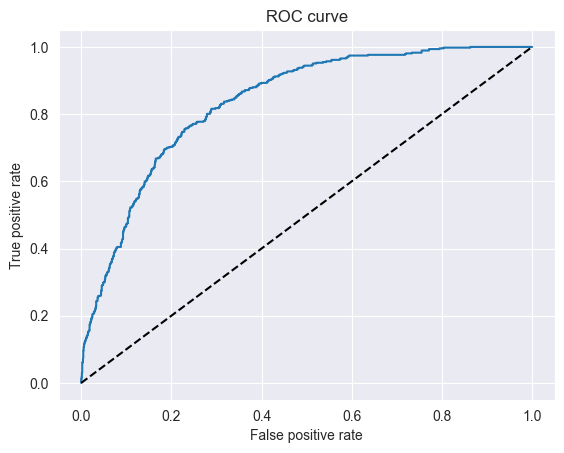

In [28]:
fpr, tpr, thr = roc_curve(y_test, y_proba_test)

plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC curve')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')

<Axes: >

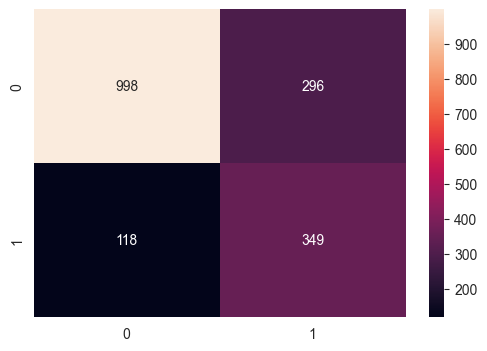

In [29]:
plt.figure(figsize=(6,4), dpi=100)
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='.4g')